In [1]:
import os

data_path = r"C:\DeepLearning\CNN_Practice\data\chest_xray"

print(os.listdir(data_path))

['chest_xray', 'test', 'train', 'val', '__MACOSX']


In [2]:
import os

for folder in ["train", "test", "val"]:
    path = os.path.join(data_path, folder)
    print(f"\n{folder}:")
    print(os.listdir(path))


train:
['NORMAL', 'PNEUMONIA']

test:
['NORMAL', 'PNEUMONIA']

val:
['NORMAL', 'PNEUMONIA']


In [3]:
for split in ["train", "test", "val"]:
    print(f"\n{split.upper()}")

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(data_path, split, class_name)

        count = len(os.listdir(class_path))

        print(f"{class_name}: {count}")


TRAIN
NORMAL: 1341
PNEUMONIA: 3875

TEST
NORMAL: 234
PNEUMONIA: 390

VAL
NORMAL: 8
PNEUMONIA: 8


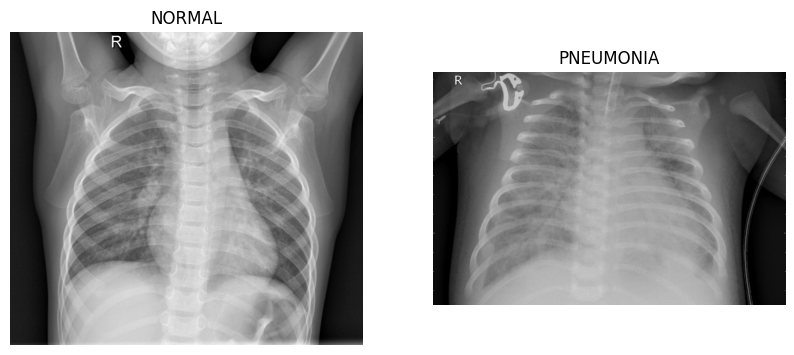

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

normal_path = os.path.join(data_path, "train", "NORMAL")
pneumonia_path = os.path.join(data_path, "train", "PNEUMONIA")

normal_image = os.path.join(normal_path, os.listdir(normal_path)[0])
pneumonia_image = os.path.join(pneumonia_path, os.listdir(pneumonia_path)[0])

normal = Image.open(normal_image)
pneumonia = Image.open(pneumonia_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [5]:
# Check image properties

print("Normal image:")
print("Size:", normal.size)
print("Mode:", normal.mode)

print("\nPneumonia image:")
print("Size:", pneumonia.size)
print("Mode:", pneumonia.mode)

Normal image:
Size: (2090, 1858)
Mode: L

Pneumonia image:
Size: (1152, 760)
Mode: L


In [6]:
import numpy as np

normal_array = np.array(normal)
pneumonia_array = np.array(pneumonia)

print("Normal")
print("Min:", normal_array.min())
print("Max:", normal_array.max())

print("\nPneumonia")
print("Min:", pneumonia_array.min())
print("Max:", pneumonia_array.max())

Normal
Min: 0
Max: 255

Pneumonia
Min: 0
Max: 255


In [7]:
normal_normalized = normal_array / 255.0
pneumonia_normalized = pneumonia_array / 255.0

print("Normal")
print("Min:", normal_normalized.min())
print("Max:", normal_normalized.max())

print("\nPneumonia")
print("Min:", pneumonia_normalized.min())
print("Max:", pneumonia_normalized.max())

Normal
Min: 0.0
Max: 1.0

Pneumonia
Min: 0.0
Max: 1.0


In [8]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True
)

print("Classes:", train_ds.class_names)


Found 5216 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

print("Normalization applied.")

Normalization applied.


In [10]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 150, 150, 1)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=True
)

print("Classes:", train_ds.class_names)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Classes: ['NORMAL', 'PNEUMONIA']


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

print("Normalization applied to training and validation datasets.")

Normalization applied to training and validation datasets.


In [13]:
train_images, train_labels = next(iter(train_ds))
val_images, val_labels = next(iter(val_ds))

print("TRAIN")
print("Images:", train_images.shape)
print("Labels:", train_labels.shape)
print("Min:", tf.reduce_min(train_images).numpy())
print("Max:", tf.reduce_max(train_images).numpy())

print("\nVALIDATION")
print("Images:", val_images.shape)
print("Labels:", val_labels.shape)
print("Min:", tf.reduce_min(val_images).numpy())
print("Max:", tf.reduce_max(val_images).numpy())

TRAIN
Images: (32, 150, 150, 1)
Labels: (32,)
Min: 0.0
Max: 1.0

VALIDATION
Images: (32, 150, 150, 1)
Labels: (32,)
Min: 0.0
Max: 1.0


In [14]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(150, 150, 1)),

    # Feature extraction
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    # Binary classification
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,635,905 (40.57 MB)

 Trainable params: 10,635,905 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8742 - loss: 0.3184 - val_accuracy: 0.9722 - val_loss: 0.0975
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9626 - loss: 0.0983 - val_accuracy: 0.9722 - val_loss: 0.0925
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9753 - loss: 0.0651 - val_accuracy: 0.9722 - val_loss: 0.0947
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9813 - loss: 0.0561 - val_accuracy: 0.9760 - val_loss: 0.0843
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9887 - loss: 0.0370 - val_accuracy: 0.9760 - val_loss: 0.0951


In [17]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

print("Test classes:", test_ds.class_names)

test_ds = test_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

Found 624 files belonging to 2 classes.
Test classes: ['NORMAL', 'PNEUMONIA']


In [18]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.7356 - loss: 1.6256
Test Accuracy: 0.7355769276618958
Test Loss: 1.6255964040756226


In [19]:
import numpy as np

y_true = []
y_prob = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

Actual labels: (624,)
Predicted labels: (624,)


[[ 71 163]
 [  2 388]]


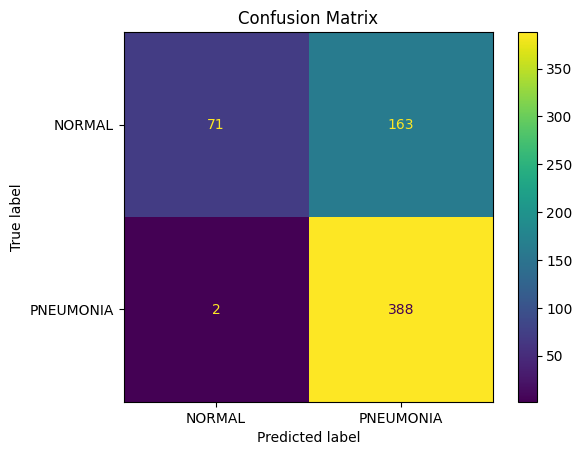

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy:    0.7356
Precision:   0.7042
Recall:      0.9949
F1 Score:    0.8247
Sensitivity: 0.9949
Specificity: 0.3034


In [22]:
import numpy as np

# Number of images in each class
normal_count = 1341
pneumonia_count = 3875

total = normal_count + pneumonia_count
num_classes = 2

normal_weight = total / (num_classes * normal_count)
pneumonia_weight = total / (num_classes * pneumonia_count)

class_weights = {
    0: normal_weight,
    1: pneumonia_weight
}

print("Class weights:")
print("NORMAL:", normal_weight)
print("PNEUMONIA:", pneumonia_weight)

Class weights:
NORMAL: 1.9448173005219984
PNEUMONIA: 0.6730322580645162


In [23]:
weighted_model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(150, 150, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

weighted_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

weighted_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,635,905 (40.57 MB)

 Trainable params: 10,635,905 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
weighted_history = weighted_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8835 - loss: 0.2726 - val_accuracy: 0.9616 - val_loss: 0.1119
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9554 - loss: 0.1089 - val_accuracy: 0.9578 - val_loss: 0.1349
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9710 - loss: 0.0822 - val_accuracy: 0.9693 - val_loss: 0.0997
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9775 - loss: 0.0606 - val_accuracy: 0.9511 - val_loss: 0.1502
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9847 - loss: 0.0455 - val_accuracy: 0.9712 - val_loss: 0.0884


In [25]:
test_loss_w, test_accuracy_w = weighted_model.evaluate(test_ds)

print("Weighted Test Accuracy:", test_accuracy_w)
print("Weighted Test Loss:", test_loss_w)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.7740 - loss: 1.2220
Weighted Test Accuracy: 0.7740384340286255
Weighted Test Loss: 1.2220189571380615


[[ 96 138]
 [  3 387]]


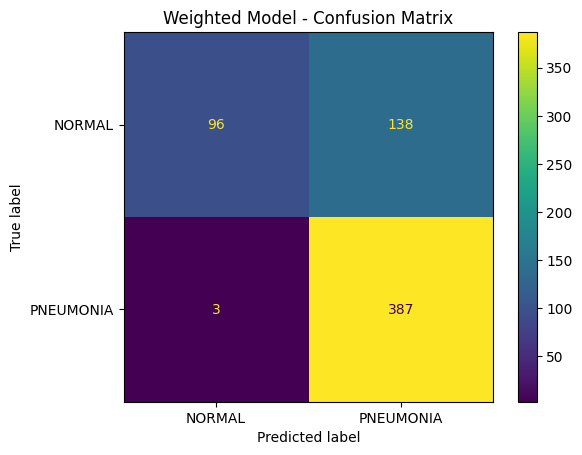

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true_w = []
y_prob_w = []

for images, labels in test_ds:
    predictions = weighted_model.predict(images, verbose=0)

    y_true_w.extend(labels.numpy())
    y_prob_w.extend(predictions.flatten())

y_true_w = np.array(y_true_w)
y_prob_w = np.array(y_prob_w)

y_pred_w = (y_prob_w >= 0.5).astype(int)

cm_w = confusion_matrix(y_true_w, y_pred_w)

print(cm_w)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Weighted Model - Confusion Matrix")
plt.show()

In [27]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

print("Data augmentation created.")

Data augmentation created.


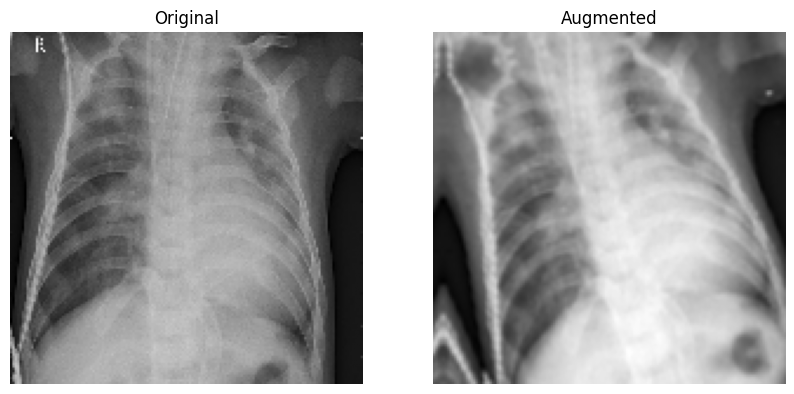

In [28]:
sample_image = train_images[0]

augmented_image = data_augmentation(
    tf.expand_dims(sample_image, axis=0),
    training=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_image[:, :, 0], cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_image[0, :, :, 0], cmap="gray")
plt.title("Augmented")
plt.axis("off")

plt.show()

In [29]:
augmented_model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(150, 150, 1)),

    # Data augmentation
    data_augmentation,

    # Feature extraction
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

augmented_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

augmented_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 150, 150, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,635,905 (40.57 MB)

 Trainable params: 10,635,905 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
augmented_history = augmented_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7208 - loss: 0.5471 - val_accuracy: 0.8782 - val_loss: 0.2984
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8658 - loss: 0.3027 - val_accuracy: 0.9233 - val_loss: 0.2039
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8982 - loss: 0.2524 - val_accuracy: 0.8849 - val_loss: 0.2757
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9051 - loss: 0.2337 - val_accuracy: 0.9578 - val_loss: 0.1266
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9238 - loss: 0.1969 - val_accuracy: 0.9569 - val_loss: 0.1280


In [31]:
test_loss_aug, test_accuracy_aug = augmented_model.evaluate(test_ds)

print("Augmented Test Accuracy:", test_accuracy_aug)
print("Augmented Test Loss:", test_loss_aug)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.8333 - loss: 0.4497
Augmented Test Accuracy: 0.8333333134651184
Augmented Test Loss: 0.44972115755081177


[[142  92]
 [ 12 378]]


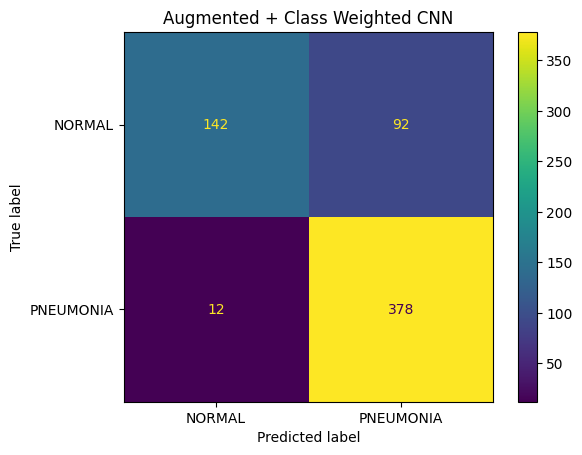

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true_aug = []
y_prob_aug = []

for images, labels in test_ds:
    predictions = augmented_model.predict(images, verbose=0)

    y_true_aug.extend(labels.numpy())
    y_prob_aug.extend(predictions.flatten())

y_true_aug = np.array(y_true_aug)
y_prob_aug = np.array(y_prob_aug)

y_pred_aug = (y_prob_aug >= 0.5).astype(int)

cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

print(cm_aug)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Augmented + Class Weighted CNN")
plt.show()

In [34]:
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

print("DenseNet121 loaded successfully!")

DenseNet121 loaded successfully!


In [35]:
inputs = tf.keras.Input(shape=(150, 150, 1))

x = tf.keras.layers.Concatenate(axis=-1)([
    inputs,
    inputs,
    inputs
])

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

advanced_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="DenseNet121_Pneumonia"
)

advanced_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

advanced_model.summary()

Model: "DenseNet121_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 150, 150, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 150, 150, 3)       │               0 │ input_layer_6[0][0],       │
│                               │                           │                 │ input_layer_6[0][0],       │
│                               │                           │                 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ densenet121 (Functional)      │ (None, 4, 4, 1024)        │       7,037,504 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 1024)              │               0 │ densenet121[0][0]          │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 1024)              │               0 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 1)                 │           1,025 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [36]:
advanced_history = advanced_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 4600s 35s/step - accuracy: 0.8030 - loss: 0.4053 - val_accuracy: 0.9147 - val_loss: 0.2236
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.8958 - loss: 0.2536 - val_accuracy: 0.9252 - val_loss: 0.1974
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.9075 - loss: 0.2219 - val_accuracy: 0.9338 - val_loss: 0.1686
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9188 - loss: 0.1914 - val_accuracy: 0.9358 - val_loss: 0.1633
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.9238 - loss: 0.1866 - val_accuracy: 0.9291 - val_loss: 0.1718


In [37]:
advanced_test_loss, advanced_test_accuracy = advanced_model.evaluate(
    test_ds
)

print("Advanced Test Accuracy:", advanced_test_accuracy)
print("Advanced Test Loss:", advanced_test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8830 - loss: 0.3159
Advanced Test Accuracy: 0.8830128312110901
Advanced Test Loss: 0.31593355536460876


In [38]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true_advanced = []
y_prob_advanced = []

for images, labels in test_ds:
    predictions = advanced_model.predict(images, verbose=0)
    
    y_true_advanced.extend(labels.numpy())
    y_prob_advanced.extend(predictions.flatten())

y_true_advanced = np.array(y_true_advanced)
y_prob_advanced = np.array(y_prob_advanced)

y_pred_advanced = (y_prob_advanced >= 0.5).astype(int)

cm_advanced = confusion_matrix(
    y_true_advanced,
    y_pred_advanced
)

print("Advanced DenseNet121 Confusion Matrix:")
print(cm_advanced)

Advanced DenseNet121 Confusion Matrix:
[[175  59]
 [ 14 376]]


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true_advanced, y_pred_advanced)
precision = precision_score(y_true_advanced, y_pred_advanced)
recall = recall_score(y_true_advanced, y_pred_advanced)
f1 = f1_score(y_true_advanced, y_pred_advanced)

tn, fp, fn, tp = cm_advanced.ravel()

specificity = tn / (tn + fp)

print("DenseNet121 Metrics")
print("--------------------")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"Sensitivity: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

DenseNet121 Metrics
--------------------
Accuracy:    0.8830
Precision:   0.8644
Recall:      0.9641
F1 Score:    0.9115
Sensitivity: 0.9641
Specificity: 0.7479


In [40]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 427
Trainable layers: 30


In [41]:
advanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [42]:
fine_tune_history = advanced_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.8914 - loss: 0.5207 - val_accuracy: 0.9415 - val_loss: 0.1407
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9255 - loss: 0.3195 - val_accuracy: 0.9415 - val_loss: 0.1384
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.9401 - loss: 0.2406 - val_accuracy: 0.9473 - val_loss: 0.1321
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.9391 - loss: 0.2103 - val_accuracy: 0.9482 - val_loss: 0.1258
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9451 - loss: 0.1807 - val_accuracy: 0.9511 - val_loss: 0.1213


In [43]:
fine_tune_test_loss, fine_tune_test_accuracy = advanced_model.evaluate(
    test_ds
)

print("Fine-Tuned DenseNet121 Test Accuracy:", fine_tune_test_accuracy)
print("Fine-Tuned DenseNet121 Test Loss:", fine_tune_test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8510 - loss: 0.4836
Fine-Tuned DenseNet121 Test Accuracy: 0.8509615659713745
Fine-Tuned DenseNet121 Test Loss: 0.48363083600997925


In [44]:
from sklearn.metrics import confusion_matrix

y_true_finetune = []
y_prob_finetune = []

for images, labels in test_ds:
    predictions = advanced_model.predict(images, verbose=0)

    y_true_finetune.extend(labels.numpy())
    y_prob_finetune.extend(predictions.flatten())

y_true_finetune = np.array(y_true_finetune)
y_prob_finetune = np.array(y_prob_finetune)

y_pred_finetune = (y_prob_finetune >= 0.5).astype(int)

cm_finetune = confusion_matrix(
    y_true_finetune,
    y_pred_finetune
)

print("Fine-Tuned DenseNet121 Confusion Matrix:")
print(cm_finetune)

Fine-Tuned DenseNet121 Confusion Matrix:
[[148  86]
 [  7 383]]


In [45]:
# Fresh DenseNet121 for final model

final_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

final_base.trainable = False

print("Fresh DenseNet121 created!")
print("Trainable:", final_base.trainable)

Fresh DenseNet121 created!
Trainable: False


In [46]:
inputs = tf.keras.Input(shape=(150, 150, 1))

# Grayscale → RGB
x = tf.keras.layers.Concatenate(axis=-1)([
    inputs,
    inputs,
    inputs
])

# Frozen pretrained DenseNet121
x = final_base(x, training=False)

# Reduce feature maps
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Regularization
x = tf.keras.layers.Dropout(0.3)(x)

# Binary classification
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

final_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MedVision_DenseNet121"
)

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "MedVision_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)    │ (None, 150, 150, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 150, 150, 3)       │               0 │ input_layer_8[0][0],       │
│                               │                           │                 │ input_layer_8[0][0],       │
│                               │                           │                 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ densenet121 (Functional)      │ (None, 4, 4, 1024)        │       7,037,504 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 1024)              │               0 │ densenet121[0][0]          │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 1024)              │               0 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 1)                 │           1,025 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [47]:
final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


C:\Users\ajayr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 531s 4s/step - accuracy: 0.7227 - loss: 0.5755 - val_accuracy: 0.8907 - val_loss: 0.2753
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 461s 3s/step - accuracy: 0.8814 - loss: 0.2772 - val_accuracy: 0.9214 - val_loss: 0.2061
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 461s 4s/step - accuracy: 0.9056 - loss: 0.2378 - val_accuracy: 0.9338 - val_loss: 0.1763
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.9154 - loss: 0.2092 - val_accuracy: 0.9367 - val_loss: 0.1679
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 461s 4s/step - accuracy: 0.9183 - loss: 0.1998 - val_accuracy: 0.9386 - val_loss: 0.1581


In [48]:
final_test_loss, final_test_accuracy = final_model.evaluate(
    test_ds
)

print("Final DenseNet121 Test Accuracy:", final_test_accuracy)
print("Final DenseNet121 Test Loss:", final_test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.8670 - loss: 0.3447
Final DenseNet121 Test Accuracy: 0.8669871687889099
Final DenseNet121 Test Loss: 0.34466752409935


In [49]:
from sklearn.metrics import confusion_matrix

y_true_final = []
y_prob_final = []

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0)

    y_true_final.extend(labels.numpy())
    y_prob_final.extend(predictions.flatten())

y_true_final = np.array(y_true_final)
y_prob_final = np.array(y_prob_final)

y_pred_final = (y_prob_final >= 0.5).astype(int)

cm_final = confusion_matrix(
    y_true_final,
    y_pred_final
)

print("Final DenseNet121 Confusion Matrix:")
print(cm_final)

Final DenseNet121 Confusion Matrix:
[[162  72]
 [ 11 379]]


In [50]:
for layer in reversed(final_model.layers):
    try:
        if len(layer.output.shape) == 4:
            print("Last 4D layer:", layer.name)
            print("Output shape:", layer.output.shape)
            break
    except:
        pass

Last 4D layer: densenet121
Output shape: (None, 4, 4, 1024)


In [51]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Model input → last convolution layer → prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Record gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        
        # Binary classification probability
        pneumonia_score = predictions[:, 0]

    # Gradients of pneumonia score
    grads = tape.gradient(
        pneumonia_score,
        conv_outputs
    )

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps using gradients
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU → keep positive influence
    heatmap = tf.maximum(heatmap, 0)

    # Normalize 0 → 1
    max_value = tf.reduce_max(heatmap)

    if max_value != 0:
        heatmap /= max_value

    return heatmap.numpy()

In [52]:
# Get one batch from test dataset
for images, labels in test_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

# Add batch dimension
sample_input = tf.expand_dims(sample_image, axis=0)

# Prediction
prediction = final_model.predict(sample_input, verbose=0)[0][0]

print("Actual Class:", "PNEUMONIA" if sample_label.numpy() == 1 else "NORMAL")
print("Pneumonia Probability:", f"{prediction:.4f}")
print("Predicted Class:", "PNEUMONIA" if prediction >= 0.5 else "NORMAL")

Actual Class: NORMAL
Pneumonia Probability: 0.4773
Predicted Class: NORMAL


In [55]:
def make_gradcam_heatmap(img_array, final_model, final_base):
    
    # Last convolutional feature layer inside DenseNet121
    target_layer = final_base.get_layer("relu")
    
    # Model to extract feature maps
    feature_model = tf.keras.Model(
        inputs=final_base.input,
        outputs=target_layer.output
    )
    
    # Final classifier layer
    classifier = final_model.layers[-1]

    # Convert grayscale → RGB
    rgb_image = tf.keras.layers.Concatenate(axis=-1)([
        img_array,
        img_array,
        img_array
    ])

    with tf.GradientTape() as tape:
        
        # Get DenseNet feature maps
        conv_outputs = feature_model(
            rgb_image,
            training=False
        )
        
        # Global Average Pooling
        pooled_features = tf.reduce_mean(
            conv_outputs,
            axis=(1, 2)
        )
        
        # Final prediction
        predictions = classifier(
            pooled_features
        )
        
        pneumonia_score = predictions[:, 0]

    # Gradients of pneumonia score
    grads = tape.gradient(
        pneumonia_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Keep positive influence
    heatmap = tf.maximum(heatmap, 0)

    # Normalize 0 → 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [56]:
heatmap = make_gradcam_heatmap(
    sample_input,
    final_model,
    final_base
)

print("Heatmap shape:", heatmap.shape)
print("Heatmap min:", heatmap.min())
print("Heatmap max:", heatmap.max())

Heatmap shape: (4, 4)
Heatmap min: 0.0
Heatmap max: 1.0


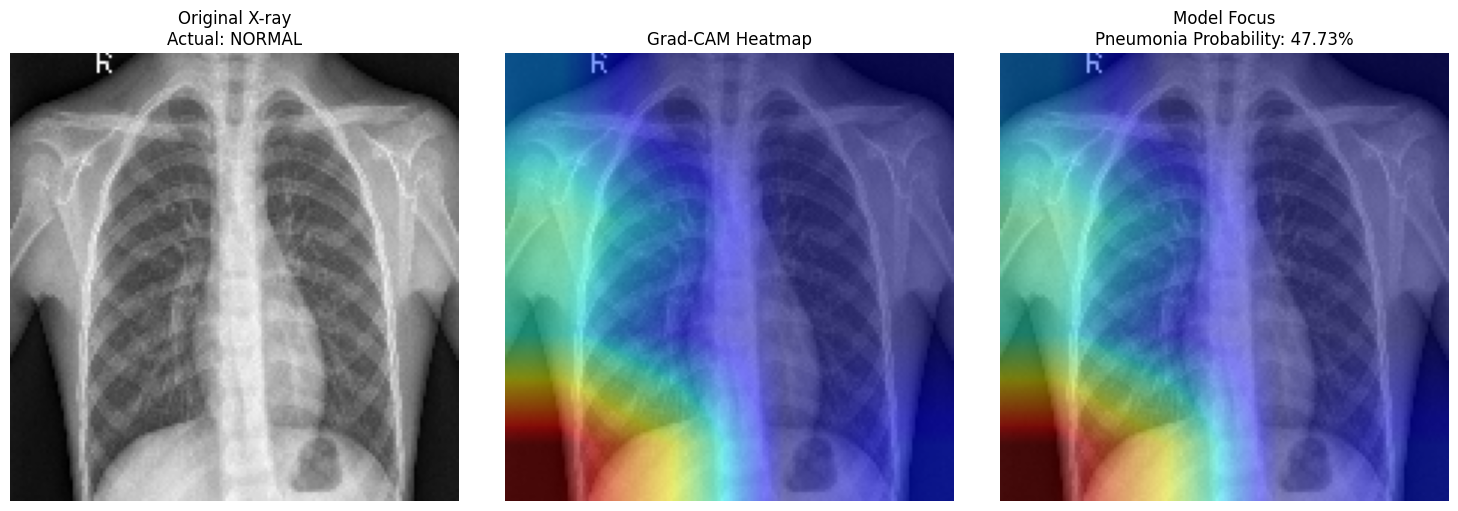

In [57]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Convert original image to numpy
original_image = sample_image.numpy().squeeze()

# Resize Grad-CAM heatmap to image size
heatmap_image = Image.fromarray(
    np.uint8(heatmap * 255)
).resize((150, 150), Image.Resampling.BILINEAR)

heatmap_resized = np.array(heatmap_image) / 255.0

# Create visualization
plt.figure(figsize=(15, 5))

# 1. Original X-ray
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap="gray")
plt.title(
    f"Original X-ray\nActual: {'PNEUMONIA' if sample_label.numpy() == 1 else 'NORMAL'}"
)
plt.axis("off")

# 2. Grad-CAM heatmap
plt.subplot(1, 3, 2)
plt.imshow(original_image, cmap="gray")
plt.imshow(heatmap_resized, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# 3. Overlay
plt.subplot(1, 3, 3)
plt.imshow(original_image, cmap="gray")
plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
plt.title(
    f"Model Focus\nPneumonia Probability: {prediction:.2%}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
normal_sample = None
pneumonia_sample = None

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0).flatten()

    for i in range(len(images)):
        prob = predictions[i]
        label = labels[i].numpy()

        # Confident NORMAL
        if label == 0 and prob < 0.2 and normal_sample is None:
            normal_sample = (
                images[i],
                labels[i],
                prob
            )

        # Confident PNEUMONIA
        if label == 1 and prob > 0.8 and pneumonia_sample is None:
            pneumonia_sample = (
                images[i],
                labels[i],
                prob
            )

        if normal_sample is not None and pneumonia_sample is not None:
            break

    if normal_sample is not None and pneumonia_sample is not None:
        break

print("Confident NORMAL found:", normal_sample is not None)
print("Confident PNEUMONIA found:", pneumonia_sample is not None)

Confident NORMAL found: True
Confident PNEUMONIA found: True


In [59]:
normal_image = normal_sample[0]
normal_label = normal_sample[1]
normal_prob = normal_sample[2]

normal_input = tf.expand_dims(normal_image, axis=0)

normal_heatmap = make_gradcam_heatmap(
    normal_input,
    final_model,
    final_base
)

print("Actual:", "NORMAL")
print("Pneumonia Probability:", f"{normal_prob:.4f}")
print("Heatmap shape:", normal_heatmap.shape)

Actual: NORMAL
Pneumonia Probability: 0.0769
Heatmap shape: (4, 4)


In [60]:
pneumonia_image = pneumonia_sample[0]
pneumonia_label = pneumonia_sample[1]
pneumonia_prob = pneumonia_sample[2]

pneumonia_input = tf.expand_dims(
    pneumonia_image,
    axis=0
)

pneumonia_heatmap = make_gradcam_heatmap(
    pneumonia_input,
    final_model,
    final_base
)

print("Actual:", "PNEUMONIA")
print("Pneumonia Probability:", f"{pneumonia_prob:.4f}")
print("Heatmap shape:", pneumonia_heatmap.shape)

Actual: PNEUMONIA
Pneumonia Probability: 0.9880
Heatmap shape: (4, 4)


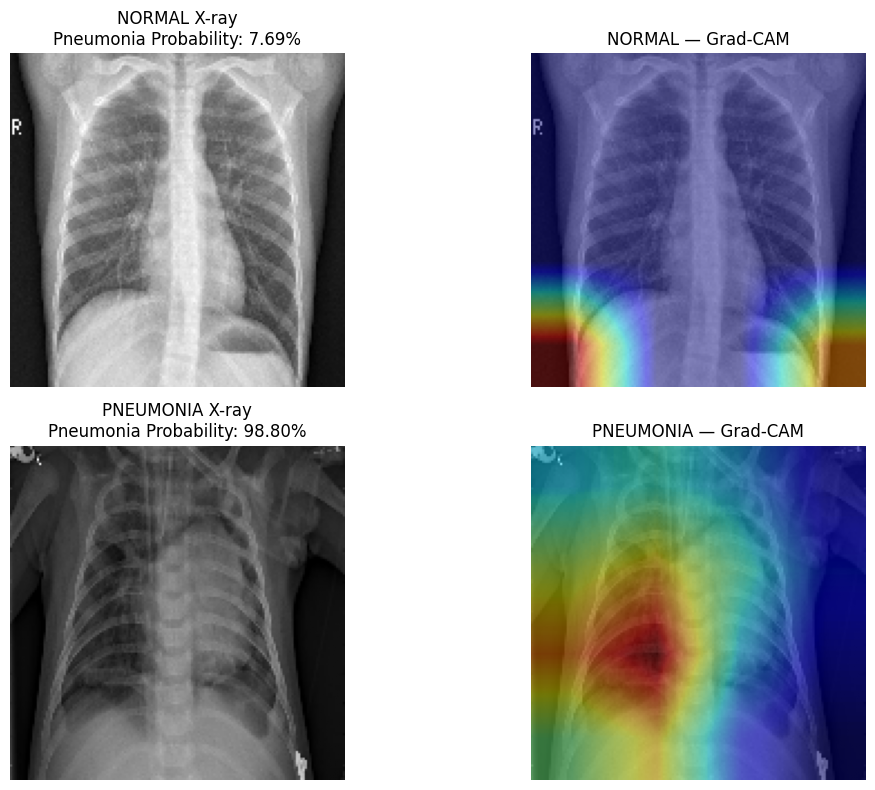

In [61]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def resize_heatmap(heatmap, size=(150, 150)):
    heatmap_img = Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(
        size,
        Image.Resampling.BILINEAR
    )
    
    return np.array(heatmap_img) / 255.0


# Resize heatmaps
normal_heatmap_resized = resize_heatmap(normal_heatmap)
pneumonia_heatmap_resized = resize_heatmap(pneumonia_heatmap)

# Convert images to numpy
normal_display = normal_image.numpy().squeeze()
pneumonia_display = pneumonia_image.numpy().squeeze()


# Create comparison
plt.figure(figsize=(12, 8))


# NORMAL
plt.subplot(2, 2, 1)
plt.imshow(normal_display, cmap="gray")
plt.title(
    f"NORMAL X-ray\n"
    f"Pneumonia Probability: {normal_prob:.2%}"
)
plt.axis("off")


plt.subplot(2, 2, 2)
plt.imshow(normal_display, cmap="gray")
plt.imshow(
    normal_heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("NORMAL — Grad-CAM")
plt.axis("off")


# PNEUMONIA
plt.subplot(2, 2, 3)
plt.imshow(pneumonia_display, cmap="gray")
plt.title(
    f"PNEUMONIA X-ray\n"
    f"Pneumonia Probability: {pneumonia_prob:.2%}"
)
plt.axis("off")


plt.subplot(2, 2, 4)
plt.imshow(pneumonia_display, cmap="gray")
plt.imshow(
    pneumonia_heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("PNEUMONIA — Grad-CAM")
plt.axis("off")


plt.tight_layout()
plt.show()

In [62]:
final_model.save("medvision_densenet121.keras")

print("MedVision model saved successfully!")

MedVision model saved successfully!


In [63]:
def predict_xray(image_path, model=final_model):
    
    # Load image as grayscale
    image = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(150, 150)
    )
    
    # Convert image to array
    image_array = tf.keras.utils.img_to_array(image)
    
    # Normalize pixels: 0-255 → 0-1
    image_array = image_array / 255.0
    
    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )
    
    # Prediction
    probability = model.predict(
        image_array,
        verbose=0
    )[0][0]
    
    # Classification
    if probability >= 0.5:
        predicted_class = "PNEUMONIA"
        confidence = probability
    else:
        predicted_class = "NORMAL"
        confidence = 1 - probability
    
    return predicted_class, confidence, probability


print("Prediction function created successfully!")

Prediction function created successfully!


In [64]:
import os

# Pick one pneumonia image from test dataset
pneumonia_folder = os.path.join(
    data_path,
    "test",
    "PNEUMONIA"
)

pneumonia_files = os.listdir(pneumonia_folder)

# Take first image
test_image_path = os.path.join(
    pneumonia_folder,
    pneumonia_files[0]
)

print("Testing image:")
print(test_image_path)

# Predict
predicted_class, confidence, probability = predict_xray(
    test_image_path
)

print("\nPrediction Result")
print("-----------------")
print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")
print("Pneumonia Probability:", f"{probability:.2%}")

Testing image:
C:\DeepLearning\CNN_Practice\data\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg

Prediction Result
-----------------
Predicted Class: PNEUMONIA
Confidence: 73.70%
Pneumonia Probability: 73.70%


In [65]:
def analyze_xray(image_path):
    
    # Load image
    image = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(150, 150)
    )
    
    # Convert to array
    image_array = tf.keras.utils.img_to_array(image)
    
    # Normalize
    image_array = image_array / 255.0
    
    # Add batch dimension
    input_image = np.expand_dims(
        image_array,
        axis=0
    )
    
    # Prediction
    probability = final_model.predict(
        input_image,
        verbose=0
    )[0][0]
    
    # Classification
    if probability >= 0.5:
        predicted_class = "PNEUMONIA"
        confidence = probability
    else:
        predicted_class = "NORMAL"
        confidence = 1 - probability
    
    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        input_image,
        final_model,
        final_base
    )
    
    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "pneumonia_probability": probability,
        "heatmap": heatmap,
        "image": image_array
    }


print("MedVision analysis pipeline created successfully!")

MedVision analysis pipeline created successfully!


In [66]:
result = analyze_xray(test_image_path)

print("MedVision Analysis")
print("------------------")
print("Predicted Class:", result["predicted_class"])
print("Confidence:", f"{result['confidence']:.2%}")
print(
    "Pneumonia Probability:",
    f"{result['pneumonia_probability']:.2%}"
)
print("Heatmap Shape:", result["heatmap"].shape)

MedVision Analysis
------------------
Predicted Class: PNEUMONIA
Confidence: 73.70%
Pneumonia Probability: 73.70%
Heatmap Shape: (4, 4)


In [67]:
def visualize_medvision_result(result):
    
    image = result["image"].squeeze()
    heatmap = result["heatmap"]
    
    predicted_class = result["predicted_class"]
    confidence = result["confidence"]
    pneumonia_probability = result["pneumonia_probability"]
    
    # Resize heatmap to image size
    heatmap_img = Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(
        (150, 150),
        Image.Resampling.BILINEAR
    )
    
    heatmap_resized = np.array(heatmap_img) / 255.0
    
    # Visualization
    plt.figure(figsize=(12, 5))
    
    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )
    plt.axis("off")
    
    # Grad-CAM
    plt.subplot(1, 2, 2)
    plt.imshow(image, cmap="gray")
    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=0.45
    )
    plt.title(
        f"Grad-CAM Explanation\n"
        f"Pneumonia Probability: {pneumonia_probability:.2%}"
    )
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

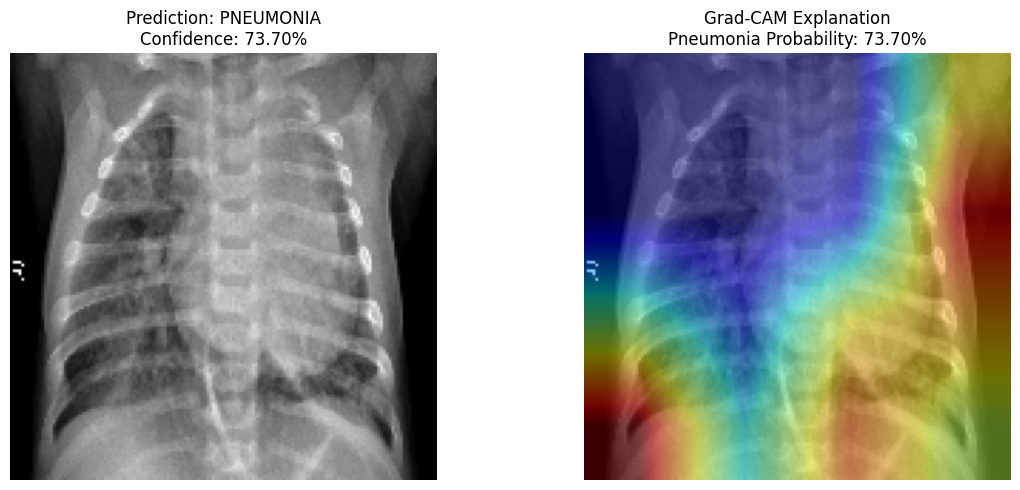

In [68]:
visualize_medvision_result(result)

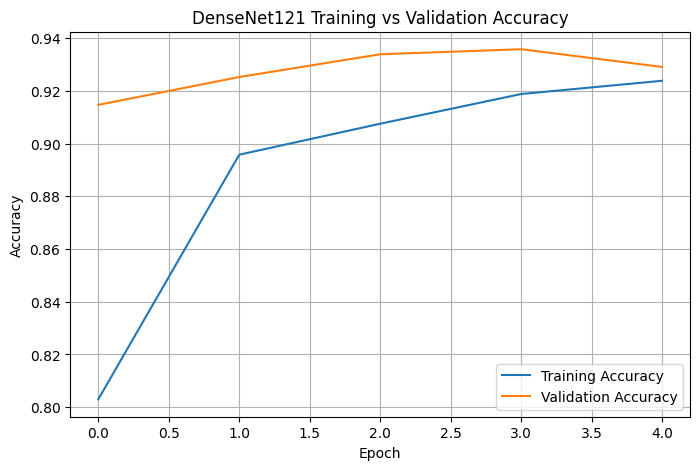

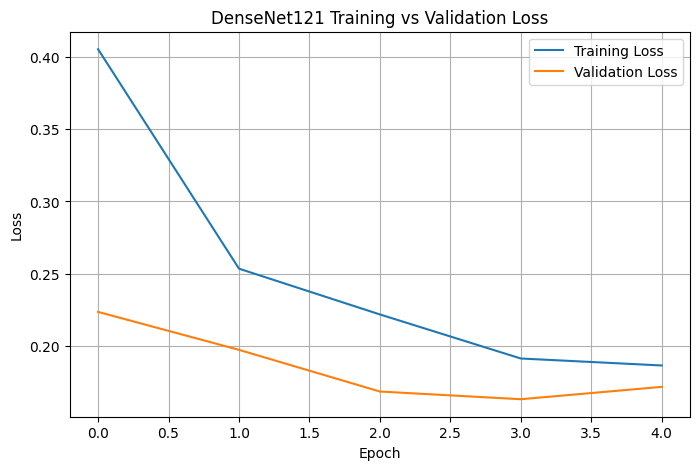

In [69]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(advanced_history.history["accuracy"], label="Training Accuracy")
plt.plot(advanced_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("DenseNet121 Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(advanced_history.history["loss"], label="Training Loss")
plt.plot(advanced_history.history["val_loss"], label="Validation Loss")
plt.title("DenseNet121 Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

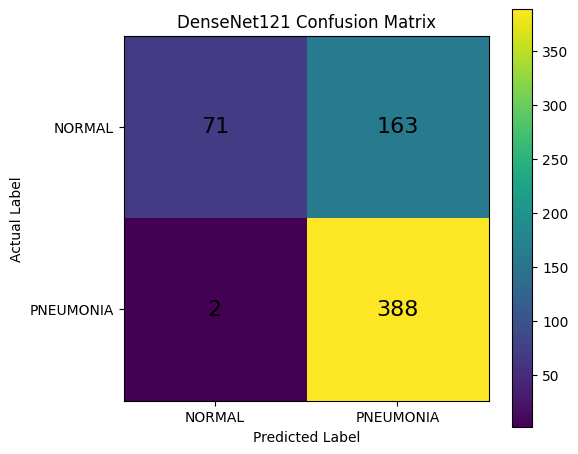

Confusion Matrix:
[[ 71 163]
 [  2 388]]


In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=16)

plt.colorbar()
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
roc_auc = roc_auc_score(y_true, y_prob)

print("DenseNet121 Evaluation Metrics")
print("--------------------------------")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"Sensitivity:  {recall:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")

DenseNet121 Evaluation Metrics
--------------------------------
Accuracy:     0.7356
Precision:    0.7042
Recall:       0.9949
Sensitivity:  0.9949
Specificity:  0.3034
F1 Score:     0.8247
ROC-AUC:      0.9075


In [72]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Fresh predictions from FINAL MODEL
y_true_final = []
y_prob_final = []

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0).flatten()

    y_true_final.extend(labels.numpy())
    y_prob_final.extend(predictions)

y_true_final = np.array(y_true_final)
y_prob_final = np.array(y_prob_final)

# Convert probabilities to classes
y_pred_final = (y_prob_final >= 0.5).astype(int)

# Confusion Matrix
cm_final = confusion_matrix(y_true_final, y_pred_final)

# Metrics
accuracy = accuracy_score(y_true_final, y_pred_final)
precision = precision_score(y_true_final, y_pred_final)
recall = recall_score(y_true_final, y_pred_final)
f1 = f1_score(y_true_final, y_pred_final)

tn, fp, fn, tp = cm_final.ravel()
specificity = tn / (tn + fp)

roc_auc = roc_auc_score(y_true_final, y_prob_final)

print("FINAL DENSENET121 EVALUATION")
print("--------------------------------")
print("Confusion Matrix:")
print(cm_final)

print(f"\nAccuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"Sensitivity:  {recall:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")

FINAL DENSENET121 EVALUATION
--------------------------------
Confusion Matrix:
[[162  72]
 [ 11 379]]

Accuracy:     0.8670
Precision:    0.8404
Recall:       0.9718
Sensitivity:  0.9718
Specificity:  0.6923
F1 Score:     0.9013
ROC-AUC:      0.9435


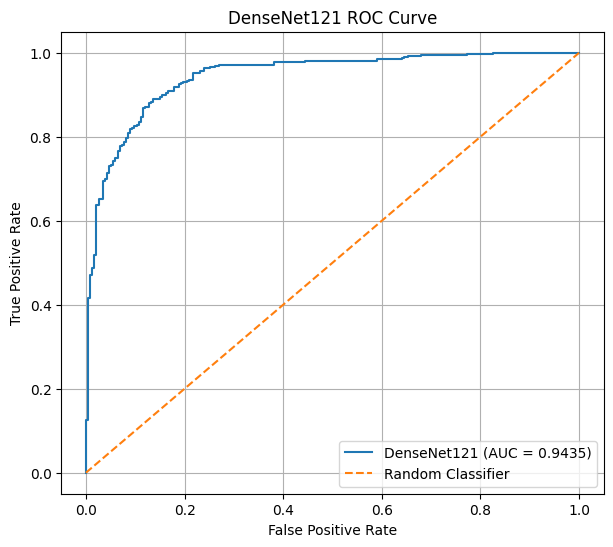

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_true_final,
    y_prob_final
)

auc_score = roc_auc_score(
    y_true_final,
    y_prob_final
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"DenseNet121 (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet121 ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [74]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "CNN + Class Weight",
        "CNN + Augmentation + Class Weight",
        "DenseNet121"
    ],
    "Accuracy": [
        72.76,
        74.68,
        88.78,
        86.70
    ],
    "Sensitivity": [
        99.49,
        99.49,
        92.82,
        97.18
    ],
    "Specificity": [
        28.21,
        33.33,
        82.05,
        69.23
    ],
    "F1 Score": [
        82.03,
        None,
        91.20,
        90.13
    ],
    "ROC-AUC": [
        None,
        None,
        None,
        94.35
    ]
})

comparison

,Model,Accuracy,Sensitivity,Specificity,F1 Score,ROC-AUC
0,Baseline CNN,72.76,99.49,28.21,82.03,NaN
1,CNN + Class Weight,74.68,99.49,33.33,NaN,NaN
2,CNN + Augmentation + Class Weight,88.78,92.82,82.05,91.20,NaN
3,DenseNet121,86.70,97.18,69.23,90.13,94.35


In [75]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, model_name):
    y_true = []
    y_prob = []

    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0).flatten()

        y_true.extend(labels.numpy())
        y_prob.extend(predictions)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred) * 100,
        "Sensitivity": recall_score(y_true, y_pred) * 100,
        "Specificity": (tn / (tn + fp)) * 100,
        "F1 Score": f1_score(y_true, y_pred) * 100,
        "ROC-AUC": roc_auc_score(y_true, y_prob) * 100
    }


results = []

results.append(evaluate_model(
    model,
    "Baseline CNN"
))

results.append(evaluate_model(
    weighted_model,
    "CNN + Class Weight"
))

results.append(evaluate_model(
    augmented_model,
    "CNN + Augmentation + Class Weight"
))

results.append(evaluate_model(
    final_model,
    "DenseNet121"
))

comparison = pd.DataFrame(results)

comparison.round(2)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1 Score,ROC-AUC
0,Baseline CNN,73.56,70.42,99.49,30.34,82.47,90.75
1,CNN + Class Weight,77.40,73.71,99.23,41.03,84.59,89.99
2,CNN + Augmentation + Class Weight,83.33,80.43,96.92,60.68,87.91,93.41
3,DenseNet121,86.70,84.04,97.18,69.23,90.13,94.35
